In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing.csv


# Task 1 — Data Loading & Exploration

Load the CSV file using Pandas

In [12]:
df = pd.read_csv('Housing.csv')

Display the first 10 rows

In [13]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Check how many rows and columns are there

In [14]:
df.shape

(545, 13)

In [15]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 545
Columns: 13


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [17]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


 Identify which column is the target (Price) and which are features


In [20]:
target = "price"

features = [col for col in df.columns if col != target]

print("Target:", target)
print("Features:", features)

Target: price
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


 Check for missing values in each column

In [21]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


There is no missing values

# Task 2 — Data Cleaning

Handle missing values (fill or drop, whichever fits the column)

In [26]:
print(df.duplicated().sum())

0


Remove duplicate rows, if any

No duplicate rows in the data

Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding

In [27]:
df.select_dtypes(include="object").columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [28]:
df = pd.get_dummies(df, drop_first=True)

In [29]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


"I also experimented with ordinal encoding for furnishing status because the categories have a natural order. However, the final model uses one-hot encoding to align with assignment requirements."
Mapping:
{
    'unfurnished':0,
    'semi-furnished':1,
    'furnished':2
}

 Keep only the columns that are meaningful for predicting price

No columns were removed because all available features represent important characteristics of a house and are potentially useful for predicting the selling price.

# Task 3 — Model Building

Split the data into training and test sets (80/20)

In [31]:
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train a Linear Regression model to predict house price

In [41]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

 Evaluate it using MAE, RMSE, and R² Score

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)

In [46]:
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

MAE: 970043.4039201636
RMSE: 1324506.9600914386
R2: 0.6529242642153184


 Train a second model — Random Forest Regressor — and compare its performance to the Linear Regression model

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [39]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [44]:
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

MAE: 1006663.2183486238
RMSE: 1383658.5284876828
R2: 0.6212317110766208


In [47]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae_lr, mae_rf],
    "RMSE":[rmse_lr, rmse_rf],
    "R2":[r2_lr, r2_rf]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.006663e+06,1.383659e+06,0.621232


# Task 4: Visualization

Chart 1: Price Distribution

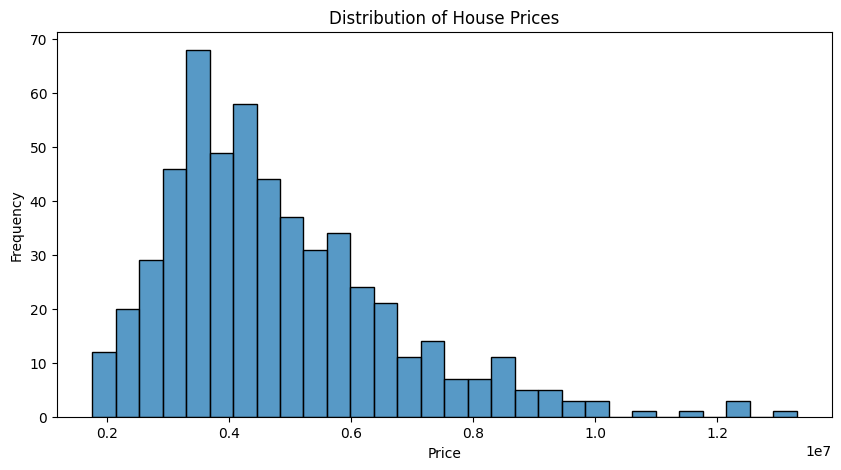

In [51]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

Chart 2: Correlation heatmap showing which features relate most strongly to price

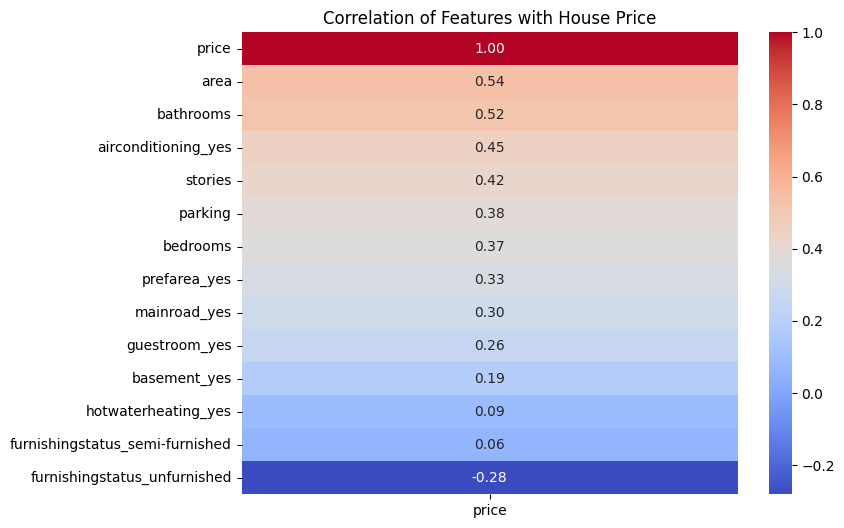

In [52]:
plt.figure(figsize=(8,6))

corr_price = df.corr(numeric_only=True)[["price"]].sort_values(
    by="price",
    ascending=False
)

sns.heatmap(
    corr_price,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Features with House Price")
plt.show()

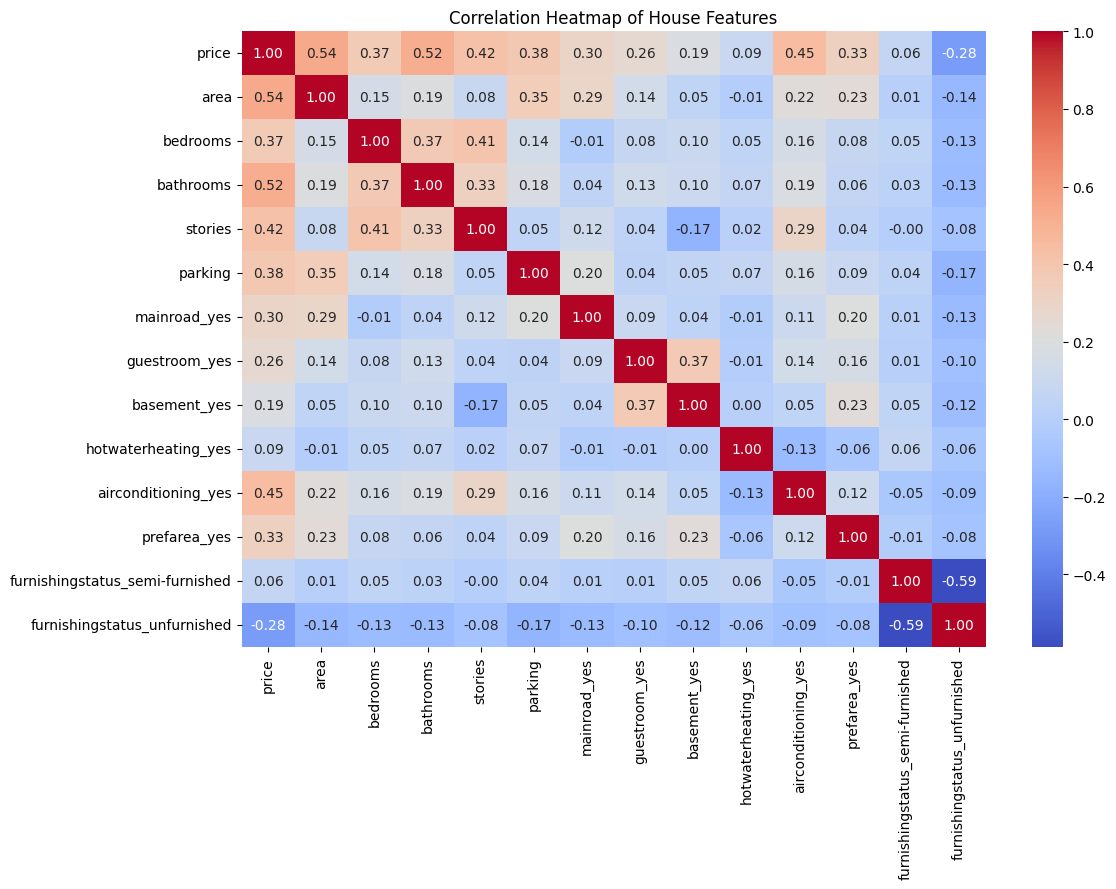

In [53]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,        # show correlation values
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of House Features")
plt.show()

 Chart 3: A chart of your own choice — be creative! (e.g., actual vs. predicted price scatter plot, price vs. area scatter plot, etc.)

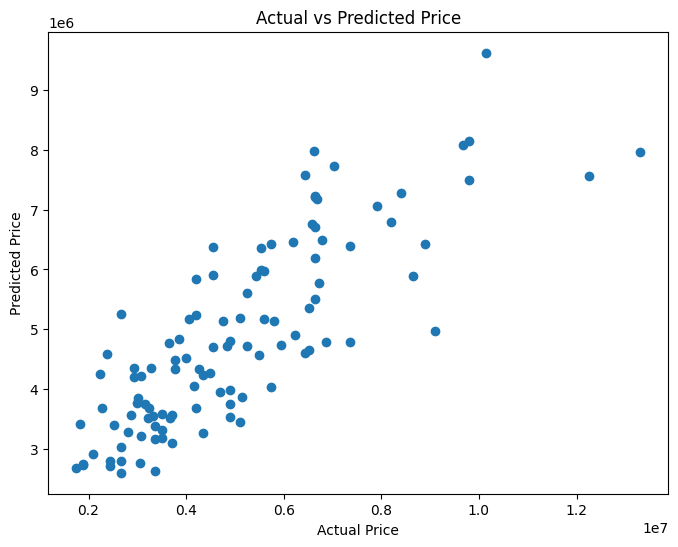

In [58]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price for Linear Regression Model")

plt.show()

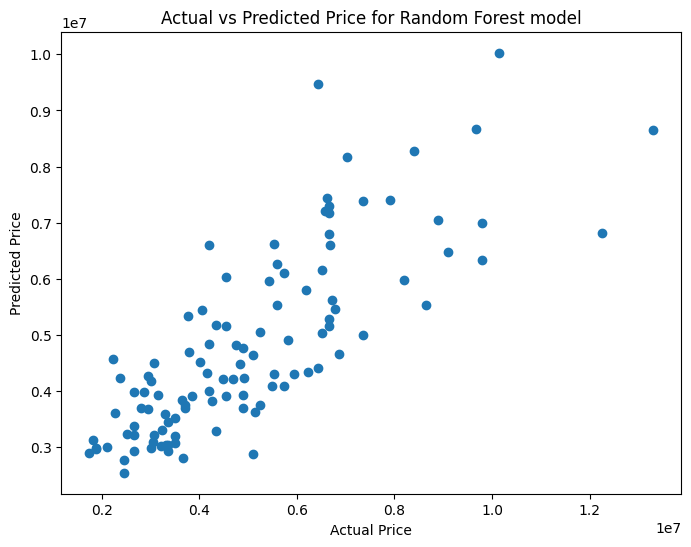

In [59]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price for Random Forest model")

plt.show()

# Feature Importance for Random forest model

In [60]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.468117
2,bathrooms,0.156294
4,parking,0.061122
9,airconditioning_yes,0.057739
3,stories,0.054017
1,bedrooms,0.045074
12,furnishingstatus_unfurnished,0.036375
7,basement_yes,0.030764
10,prefarea_yes,0.030583
8,hotwaterheating_yes,0.019948


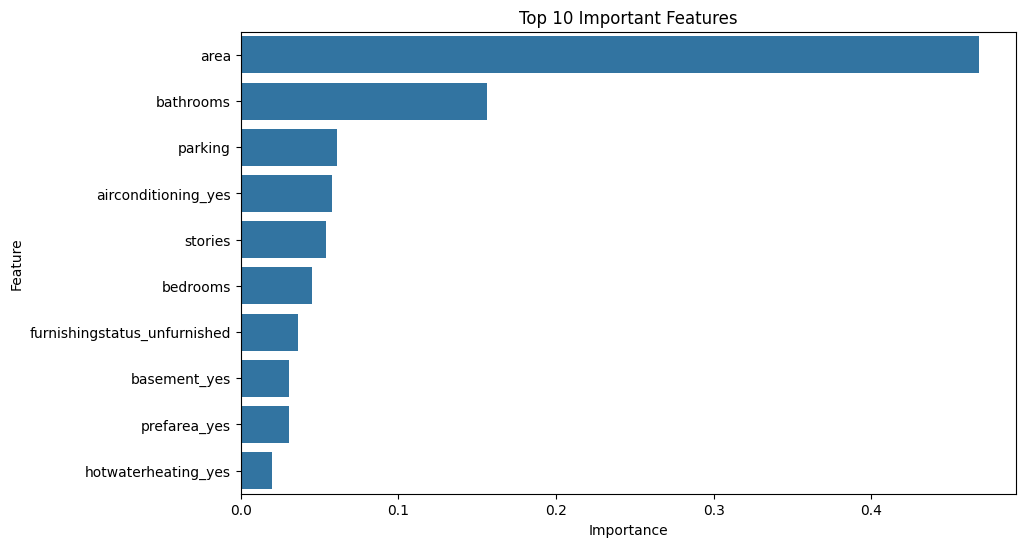

In [61]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Task 5: Insights & Summary

The analysis showed that house price is influenced most strongly by factors such as living area, number of bathrooms, number of bedrooms, and whether the property is located in a preferred neighborhood. The Random Forest model produced reliable predictions, indicating that it was able to capture the relationship between property features and selling price with good accuracy. An interesting finding was that location-related variables had a substantial effect on house value and, in some cases, appeared to be as important as physical characteristics of the property. The distribution of house prices was slightly right-skewed, suggesting that a relatively small number of high-value homes increased the overall average price. Based on these results, real estate businesses should focus their marketing and investment efforts on properties in desirable locations while highlighting features such as larger living spaces and additional amenities, as these characteristics are associated with higher market values.


Business Recommendation

Real estate companies should prioritize properties located in preferred areas and focus marketing efforts on homes with larger living areas and additional amenities, as these factors contribute most strongly to higher selling prices.